# Notebook 02 — Inyección de Ataques FDI sobre Datos Reales

**TFG:** Detección de Anomalías de Consumo Eléctrico en Edge Computing para la Mitigación de Ataques FDI  
**Autor:** Matvey Sinelnik

---

## Filosofía de diseño

Este notebook prepara los datos para evaluar modelos de detección de anomalías en edge computing.
Cada decisión se toma respondiendo a una pregunta concreta:

| Pregunta | Decisión | Por qué |
|----------|----------|---------|
| ¿Datos sintéticos o reales? | **Reales (UCI)** | Los modelos deben aprender patrones de consumo genuinos, no artefactos de un generador |
| ¿Cuántos tipos de ataque? | **7 tipos en 3 categorías** | Suficientes para cubrir el espacio de amenazas FDI; pocos para que cada tipo tenga análisis profundo |
| ¿Proporción de ataques? | **Variable** (~2-8%) | Se usan métricas independientes del umbral (AUC); el umbral se optimiza en val set |
| ¿Qué features modifica el atacante? | **Solo GAP y Voltage** | Son las lecturas del smart meter; GI y Sub_meterings son mediciones físicas independientes |
| ¿Severidad? | **3 niveles (low/med/high)** | Permite medir sensibilidad de cada modelo a la intensidad del ataque |
| ¿Cómo medir éxito de detección? | **Latencia + AUC + Recall@Severity** | Para edge, importa cuánto tarda en alertar, no solo si detecta |

### Tipos de ataque eliminados (respecto a versiones anteriores)

Se eliminan **8 tipos** que estaban en la v1 del notebook:

- **`correlated_scaling`, `adversarial`, `load_shift`**: diseñados para evadir VI_residual por construcción. Conclusión predeterminada → no es un hallazgo. Se discuten como *limitación conocida* en Cap. 6.
- **`weekend_mimicry`, `seasonal_swap`**: variantes de replay con complejidad adicional pero sin insight diferente.
- **`pulse`**: se subsume en `step` (un pulse es un step que revierte — los modelos por ventana lo ven igual).
- **`intermittent`**: patrón ON/OFF artificial que no corresponde a ataques FDI documentados en la literatura.
- **`smooth_decay`**: es un ramp suavizado — redundante.

### Los 7 tipos finales

| # | Categoría | Tipo | Qué hace | Señal de detección esperada |
|---|-----------|------|----------|---------------------------|
| 1 | Magnitud | `scaling` | P × α | VI_residual, nivel absoluto |
| 2 | Magnitud | `offset` | P + δ | VI_residual, nivel absoluto |
| 3 | Magnitud | `noise` | P + N(0,σ) | Varianza anómala |
| 4 | Temporal | `ramp` | Pendiente progresiva | Tendencia, diferencia primera |
| 5 | Temporal | `step` | Cambio de nivel abrupto | Discontinuidad, VI_residual |
| 6 | Patrón | `replay` | Sustituye por segmento histórico | Contexto temporal incorrecto |
| 7 | Físico | `voltage_spoof` | Reduce P y falsifica V | VI_residual parcial, distribución V |

## 0. Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, time, warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('OK')

OK


## 1. Carga de Datos y Split Temporal

```
|<────────────── 70% (pre-cutoff) ──────────────>|<────── 30% ──────>|
|<─────── Train (90% de pre-cutoff) ──────>| Val |                    |
|         Datos limpios para modelos        10%  |  Test con ataques  |
|                                      (umbral)  |  (evaluación)      |
```

In [16]:
# ============================================================
# RUTAS — AJUSTAR BASE_DIR según tu estructura
# ============================================================
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'

# Estructura de carpetas:
#   BASE_DIR/
#   ├── uci_clean_full.csv          ← output del Notebook 01 (fuente)
#   ├── data/                       ← outputs de este notebook
#   │   ├── train_clean.csv
#   │   ├── val_with_attacks.csv
#   │   ├── test_with_attacks.csv
#   │   ├── attack_log_test.csv
#   │   ├── attack_log_val.csv
#   │   └── pipeline_config.json
#   ├── 01_HouseholdAnalisis.ipynb
#   ├── 02_FDI_Injection.ipynb
#   ├── 03_Isolation_Forest.ipynb
#   └── ...

DATA_DIR = os.path.join(BASE_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)

FEATURE_COLS = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

# Carga del dataset limpio (output del Notebook 01)
df_full = pd.read_csv(
    os.path.join(BASE_DIR, 'uci_clean_full.csv'),
    index_col='datetime', parse_dates=True
)
df_full = df_full[FEATURE_COLS].dropna()

# Split temporal
CUTOFF = pd.Timestamp('2009-09-20 12:45:00')
df_pre  = df_full[df_full.index < CUTOFF]
df_test = df_full[df_full.index >= CUTOFF].copy()

val_idx = df_pre.index[int(len(df_pre) * 0.90)]
df_train = df_pre[df_pre.index < val_idx].copy()
df_val   = df_pre[df_pre.index >= val_idx].copy()

print('SPLIT TEMPORAL')
print('=' * 70)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    g = d['Global_active_power']
    print(f'  {nm:6s} {len(d):>10,} filas  '
          f'{d.index.min().date()} → {d.index.max().date()}  '
          f'GAP: μ={g.mean():.3f} σ={g.std():.3f}')
print(f'  {"Total":6s} {len(df_train)+len(df_val)+len(df_test):>10,}')
print(f'\nDirectorio de datos: {DATA_DIR}')


SPLIT TEMPORAL
  Train   1,300,061 filas  2006-12-16 → 2009-06-09  GAP: μ=1.125 σ=1.114
  Val       144,452 filas  2009-06-09 → 2009-09-20  GAP: μ=0.742 σ=0.770
  Test      604,999 filas  2009-09-20 → 2010-11-26  GAP: μ=1.104 σ=0.973
  Total   2,049,512

Directorio de datos: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/data


## 2. Configuración de Ataques

### Severidad

La severidad controla la **magnitud relativa** del ataque respecto al consumo normal.
Se define como fracción del rango dinámico de GAP.

| Nivel | Factor de intensidad | Ejemplo (scaling) | Dificultad detección |
|-------|---------------------|-------------------|---------------------|
| `low` | 0.10 – 0.25 | P × 0.75-0.90 | Alta (se confunde con variabilidad natural) |
| `medium` | 0.25 – 0.50 | P × 0.50-0.75 | Media |
| `high` | 0.50 – 0.80 | P × 0.20-0.50 | Baja (claramente anómalo) |

### Episodios

- **50 episodios/tipo** en test → **350 episodios totales**
- **Distribución de severidad**: 40% low / 35% medium / 25% high  
  (sesgo hacia low porque es el caso más interesante para evaluar sensibilidad)
- **Duración**: 15-180 minutos (uniforme)
- **Sin solapamiento** entre episodios

In [17]:
# Configuración
ATTACK_TYPES = ['scaling', 'offset', 'noise', 'ramp', 'step', 'replay', 'voltage_spoof']

CATEGORIES = {
    'Magnitud':  ['scaling', 'offset', 'noise'],
    'Temporal':  ['ramp', 'step'],
    'Patrón':    ['replay'],
    'Físico':    ['voltage_spoof'],
}

CAT_COLORS = {
    'Magnitud': '#e74c3c', 'Temporal': '#3498db',
    'Patrón': '#9b59b6',   'Físico': '#27ae60',
}

SEVERITY_DIST = {'low': 0.40, 'medium': 0.35, 'high': 0.25}

CLIP = {
    'Global_active_power':   (0.076, 15.0),
    'Global_reactive_power': (0.0,   1.5),
    'Voltage':               (220.0, 260.0),
}

# Estadísticas de referencia del train
GAP_TRAIN_VALUES = df_train['Global_active_power'].values.copy()
GAP_STD  = float(df_train['Global_active_power'].std())
GAP_MEAN = float(df_train['Global_active_power'].mean())

N_EPISODES = 50
DUR_MIN, DUR_MAX = 15, 180

print(f'Configuración:')
print(f'  {len(ATTACK_TYPES)} tipos × {N_EPISODES} episodios = {len(ATTACK_TYPES)*N_EPISODES} episodios en test')
print(f'  Severidad: {SEVERITY_DIST}')
print(f'  Duración: {DUR_MIN}-{DUR_MAX} min')
print(f'  GAP train: μ={GAP_MEAN:.3f} σ={GAP_STD:.3f}')

Configuración:
  7 tipos × 50 episodios = 350 episodios en test
  Severidad: {'low': 0.4, 'medium': 0.35, 'high': 0.25}
  Duración: 15-180 min
  GAP train: μ=1.125 σ=1.114


## 3. Implementación de Ataques

In [18]:
def severity_factor(rng, severity):
    '''Factor de intensidad dentro del rango de la severidad.'''
    ranges = {'low': (0.10, 0.25), 'medium': (0.25, 0.50), 'high': (0.50, 0.80)}
    lo, hi = ranges[severity]
    return float(rng.uniform(lo, hi))


def apply_attack(attack_type, gap, voltage, rng, severity='medium'):
    '''
    Aplica un ataque FDI.
    
    PRINCIPIO: el atacante controla las lecturas del smart meter (GAP, Voltage).
    NO controla: Global_intensity (corriente física), Sub_meterings (circuitos independientes).
    
    Args:
        attack_type : str
        gap         : ndarray — Global_active_power original de la ventana
        voltage     : ndarray — Voltage original
        rng         : numpy Generator
        severity    : 'low' | 'medium' | 'high'
    
    Returns:
        gap_out, voltage_out, params_dict
    '''
    n  = len(gap)
    sf = severity_factor(rng, severity)
    gap_out = gap.copy()
    v_out   = voltage.copy()
    params  = {'severity': severity, 'intensity': round(sf, 4)}
    
    if attack_type == 'scaling':
        # Robo proporcional: multiplica por (1 - sf)
        factor = 1.0 - sf
        gap_out = gap * factor
        params['factor'] = round(factor, 4)
    
    elif attack_type == 'offset':
        # Resta constante proporcional a la media de la ventana
        delta = -sf * gap.mean()
        gap_out = gap + delta
        params['delta_kw'] = round(delta, 4)
    
    elif attack_type == 'noise':
        # Ruido gaussiano calibrado respecto a la std global
        sigma = sf * GAP_STD
        gap_out = gap + rng.normal(0, sigma, n)
        params['sigma_kw'] = round(sigma, 4)
    
    elif attack_type == 'ramp':
        # Pendiente lineal progresiva
        delta_end = -sf * gap.mean() * 1.5
        gap_out = gap + np.linspace(0, delta_end, n)
        params['delta_end_kw'] = round(delta_end, 4)
    
    elif attack_type == 'step':
        # Cambio de nivel desde un punto intermedio
        step_at = int(n * rng.uniform(0.2, 0.5))
        delta = -sf * gap.mean() * 1.2
        gap_out = gap.copy()
        gap_out[step_at:] += delta
        params['delta_kw'] = round(delta, 4)
        params['step_at'] = step_at
    
    elif attack_type == 'replay':
        # Sustituye por segmento del train (blend según severidad)
        max_off = max(1, len(GAP_TRAIN_VALUES) - n)
        offset  = int(rng.integers(0, max_off))
        src = GAP_TRAIN_VALUES[offset: offset + n]
        if len(src) < n:
            src = np.tile(GAP_TRAIN_VALUES, 3)[offset: offset + n]
        gap_out = gap * (1 - sf) + src[:n] * sf
        params['blend'] = round(sf, 4)
    
    elif attack_type == 'voltage_spoof':
        # Reduce GAP y falsifica Voltage de forma imperfecta
        factor = 1.0 - sf
        gap_out = gap * factor
        # Voltage ajustado con error (±3% del factor ideal)
        v_error = factor + rng.normal(0, 0.03, n)
        v_out = np.clip(voltage * v_error, *CLIP['Voltage'])
        params['factor'] = round(factor, 4)
    
    else:
        raise ValueError(f'Tipo desconocido: {attack_type}')
    
    gap_out = np.clip(gap_out, *CLIP['Global_active_power'])
    
    return gap_out, v_out, params


print('apply_attack definido')

apply_attack definido


## 4. Motor de Inyección

In [19]:
def inject_attacks(df_target, n_episodes=N_EPISODES, seed=42):
    '''
    Inyecta ataques FDI con severidad variable.
    
    Returns:
        df_out     : DataFrame con columnas adicionales:
                     GAP_original, label, attack_type, severity, episode_id
        attack_log : lista de dicts con metadatos por episodio
    '''
    rng = np.random.default_rng(seed)
    
    df_out = df_target[FEATURE_COLS].copy()
    df_out['GAP_original'] = df_out['Global_active_power'].copy()
    df_out['label']        = 0
    df_out['attack_type']  = 'none'
    df_out['severity']     = 'none'
    df_out['episode_id']   = -1
    
    n = len(df_out)
    margin = max(200, int(n * 0.005))
    occupied = np.zeros(n, dtype=bool)
    log = []
    episode_counter = 0
    
    for attack_type in ATTACK_TYPES:
        # Distribuir por severidad
        plan = []
        for sev, frac in SEVERITY_DIST.items():
            plan.extend([sev] * int(n_episodes * frac))
        # Rellenar hasta n_episodes
        while len(plan) < n_episodes:
            plan.append('medium')
        rng.shuffle(plan)
        
        injected = 0
        attempts = 0
        
        while injected < n_episodes and attempts < n_episodes * 30:
            attempts += 1
            dur = int(rng.integers(DUR_MIN, DUR_MAX + 1))
            max_start = n - dur - margin
            if max_start <= margin:
                continue
            start = int(rng.integers(margin, max_start))
            end = start + dur
            
            if occupied[start:end].any():
                continue
            
            idxs = df_out.index[start:end]
            gap_orig = df_out.loc[idxs, 'GAP_original'].values
            v_orig   = df_out.loc[idxs, 'Voltage'].values
            sev      = plan[injected]
            
            gap_new, v_new, params = apply_attack(
                attack_type, gap_orig, v_orig, rng, severity=sev
            )
            
            df_out.loc[idxs, 'Global_active_power'] = gap_new
            df_out.loc[idxs, 'Voltage']             = v_new
            df_out.loc[idxs, 'label']               = 1
            df_out.loc[idxs, 'attack_type']          = attack_type
            df_out.loc[idxs, 'severity']             = sev
            df_out.loc[idxs, 'episode_id']           = episode_counter
            
            occupied[start:end] = True
            injected += 1
            
            log.append({
                'episode_id': episode_counter,
                'type':       attack_type,
                'severity':   sev,
                'start':      str(idxs[0]),
                'end':        str(idxs[-1]),
                'duration':   dur,
                'n_samples':  len(idxs),
                'params':     params,
            })
            episode_counter += 1
    
    return df_out, log


print('inject_attacks definido')

inject_attacks definido


## 5. Ejecución: Inyección en Test y Validation

In [20]:
# ── Test set ──────────────────────────────────────────────────
print('Inyectando en test set...')
t0 = time.time()
df_test_atk, test_log = inject_attacks(df_test, n_episodes=N_EPISODES, seed=42)
print(f'  {time.time()-t0:.1f}s')

# ── Validation set ────────────────────────────────────────────
val_n_eps = max(5, int(N_EPISODES * len(df_val) / len(df_test)))
print(f'Inyectando en val set ({val_n_eps} ep/tipo)...')
t0 = time.time()
df_val_atk, val_log = inject_attacks(df_val, n_episodes=val_n_eps, seed=777)
print(f'  {time.time()-t0:.1f}s')

# ── Resumen ───────────────────────────────────────────────────
print()
print('=' * 70)
for name, df_a, lg in [('Test', df_test_atk, test_log), ('Val', df_val_atk, val_log)]:
    n_t = len(df_a)
    n_a = (df_a['label']==1).sum()
    print(f'{name}: {n_t:,} total | {n_a:,} ataque ({n_a/n_t*100:.1f}%) | {len(lg)} episodios')
print()

# Tabla por tipo y severidad (test)
log_df = pd.DataFrame(test_log)
print('Test — Episodios por tipo × severidad:')
pivot = log_df.groupby(['type', 'severity']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=['low', 'medium', 'high'], fill_value=0)
pivot['Total'] = pivot.sum(axis=1)
# Añadir fila de duracion media
dur_by_type = log_df.groupby('type')['duration'].mean()
pivot['Dur_media'] = dur_by_type.round(0).astype(int)
print(pivot.to_string())
print(f'\nMuestras atacadas totales: {(df_test_atk["label"]==1).sum():,}')

Inyectando en test set...
  0.5s
Inyectando en val set (11 ep/tipo)...
  0.1s

Test: 604,999 total | 31,272 ataque (5.2%) | 350 episodios
Val: 144,452 total | 7,207 ataque (5.0%) | 77 episodios

Test — Episodios por tipo × severidad:
severity       low  medium  high  Total  Dur_media
type                                              
noise           20      18    12     50         92
offset          20      18    12     50         89
ramp            20      18    12     50         91
replay          20      18    12     50         86
scaling         20      18    12     50         83
step            20      18    12     50        100
voltage_spoof   20      18    12     50         85

Muestras atacadas totales: 31,272


## 6. Visualización

### 6.1 Un ejemplo por tipo (severidad medium)

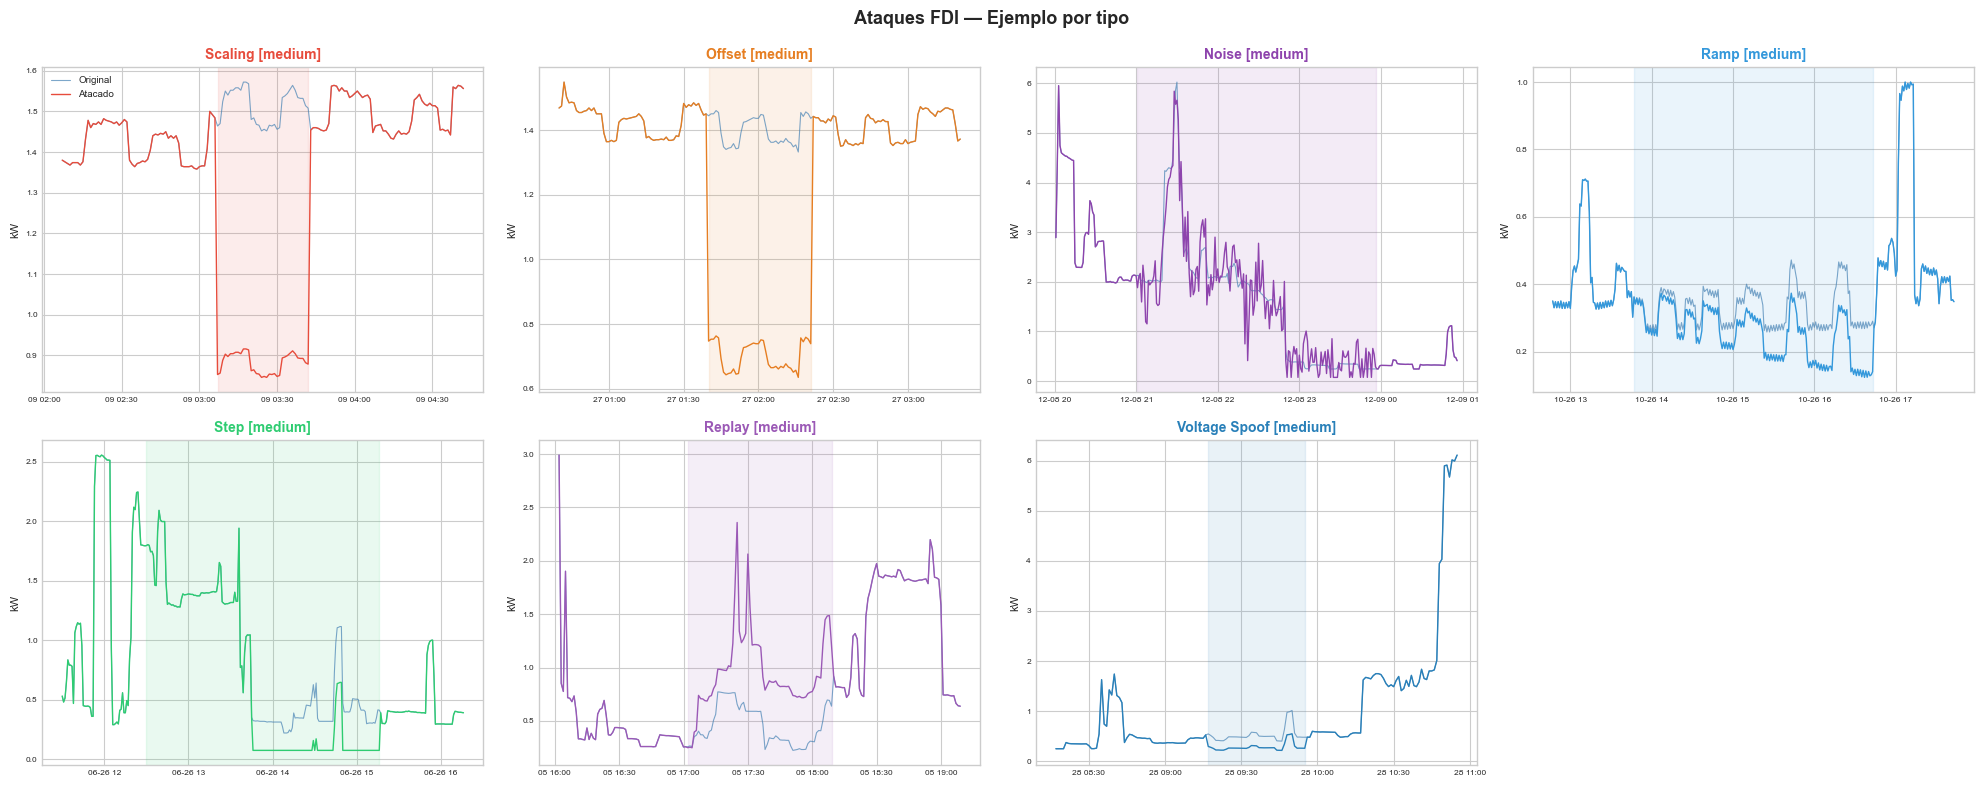

In [21]:
COLORS = {
    'scaling': '#e74c3c', 'offset': '#e67e22', 'noise': '#8e44ad',
    'ramp': '#3498db', 'step': '#2ecc71', 'replay': '#9b59b6',
    'voltage_spoof': '#2980b9',
}

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, atype in enumerate(ATTACK_TYPES):
    ax = axes[i]
    color = COLORS[atype]
    
    # Buscar episodio medium
    eps = [e for e in test_log if e['type']==atype and e['severity']=='medium']
    if not eps:
        eps = [e for e in test_log if e['type']==atype]
    ep = eps[0]
    
    buf = pd.Timedelta(minutes=60)
    vis = df_test_atk.loc[pd.Timestamp(ep['start'])-buf : pd.Timestamp(ep['end'])+buf]
    
    ax.plot(vis.index, vis['GAP_original'], 'steelblue', lw=0.8, alpha=0.7, label='Original')
    ax.plot(vis.index, vis['Global_active_power'], color=color, lw=1.0, label='Atacado')
    ax.axvspan(pd.Timestamp(ep['start']), pd.Timestamp(ep['end']), alpha=0.10, color=color)
    ax.set_title(f"{atype.replace('_',' ').title()} [{ep['severity']}]",
                 fontsize=10, fontweight='bold', color=color)
    ax.tick_params(labelsize=6)
    ax.set_ylabel('kW', fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Ataques FDI — Ejemplo por tipo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Efecto de la severidad (scaling)

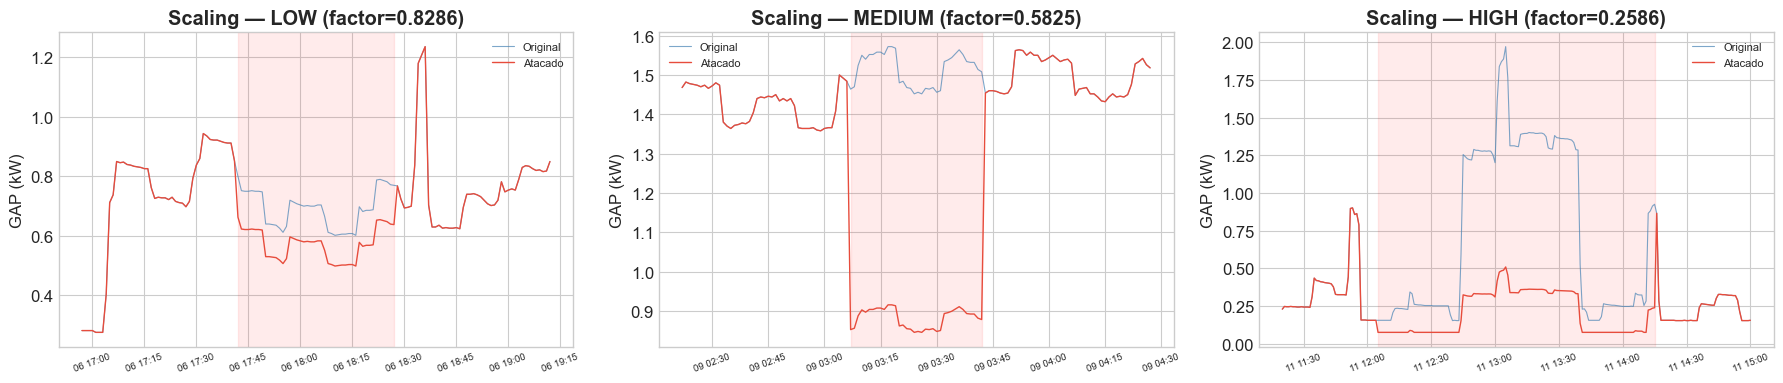

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, sev in zip(axes, ['low', 'medium', 'high']):
    eps = [e for e in test_log if e['type']=='scaling' and e['severity']==sev]
    if not eps: continue
    ep = eps[0]
    buf = pd.Timedelta(minutes=45)
    vis = df_test_atk.loc[pd.Timestamp(ep['start'])-buf : pd.Timestamp(ep['end'])+buf]
    
    ax.plot(vis.index, vis['GAP_original'], 'steelblue', lw=0.8, alpha=0.7, label='Original')
    ax.plot(vis.index, vis['Global_active_power'], '#e74c3c', lw=1.0, label='Atacado')
    ax.axvspan(pd.Timestamp(ep['start']), pd.Timestamp(ep['end']), alpha=0.08, color='red')
    factor = ep['params'].get('factor', '?')
    ax.set_title(f'Scaling — {sev.upper()} (factor={factor})', fontweight='bold')
    ax.set_ylabel('GAP (kW)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=20)
plt.tight_layout()
plt.show()

## 7. Análisis del Residual Físico (VI)

$$\text{VI\_residual} = P_{\text{reportado}} - \frac{V \times I}{1000}$$

Bajo condiciones normales, este residual refleja el factor de potencia cos(φ) y es estable.
Un ataque que modifica $P$ sin cambiar $I$ (corriente física) **rompe esta relación**.

In [23]:
# Calcular VI residual para test
df_test_atk['VI_estimated'] = df_test_atk['Voltage'] * df_test_atk['Global_intensity'] / 1000.0
df_test_atk['VI_residual']  = df_test_atk['Global_active_power'] - df_test_atk['VI_estimated']
df_test_atk['VI_res_orig']  = df_test_atk['GAP_original'] - df_test_atk['VI_estimated']

# Tabla: |VI residual| promedio por tipo × severidad
print('|VI residual| promedio por tipo y severidad:')
print(f'  {"Tipo":18s} {"Normal":>8s}  {"Low":>8s}  {"Med":>8s}  {"High":>8s}')
print('  ' + '-' * 50)

vi_normal = df_test_atk.loc[df_test_atk['label']==0, 'VI_residual'].abs().mean()
for t in ATTACK_TYPES:
    row = f'  {t:18s} {vi_normal:>8.4f}'
    for sev in ['low', 'medium', 'high']:
        mask = (df_test_atk['attack_type']==t) & (df_test_atk['severity']==sev)
        if mask.sum() > 0:
            val = df_test_atk.loc[mask, 'VI_residual'].abs().mean()
            row += f'  {val:>8.4f}'
        else:
            row += f'  {"—":>8s}'
    print(row)

|VI residual| promedio por tipo y severidad:
  Tipo                 Normal       Low       Med      High
  --------------------------------------------------
  scaling              0.0281    0.2072    0.4331    0.6006
  offset               0.0281    0.1726    0.4432    0.8454
  noise                0.0281    0.1679    0.2931    0.4542
  ramp                 0.0281    0.1550    0.2291    0.3954
  step                 0.0281    0.2108    0.2553    0.5069
  replay               0.0281    0.2517    0.4321    0.5211
  voltage_spoof        0.0281    0.1519    0.3183    0.4072


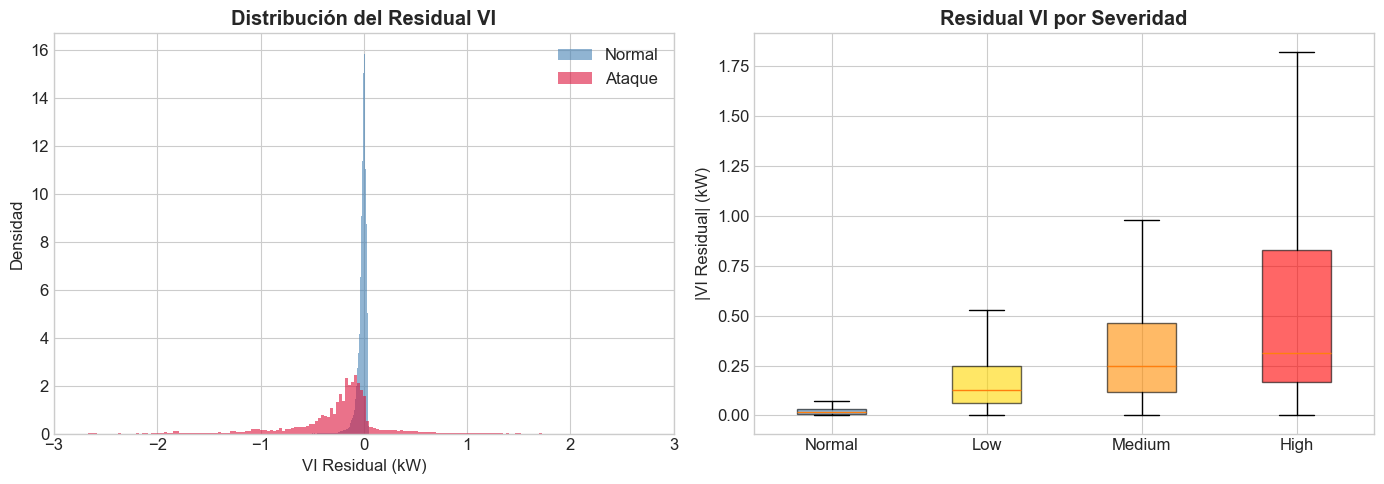

In [24]:
# Visualización: distribución del residual VI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histograma normal vs ataque
ax = axes[0]
vi_norm = df_test_atk.loc[df_test_atk['label']==0, 'VI_residual'].values
vi_atk  = df_test_atk.loc[df_test_atk['label']==1, 'VI_residual'].values
ax.hist(vi_norm, bins=200, density=True, alpha=0.6, color='steelblue', label='Normal')
ax.hist(vi_atk,  bins=200, density=True, alpha=0.6, color='crimson', label='Ataque')
ax.set_xlim(-3, 3)
ax.set_xlabel('VI Residual (kW)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución del Residual VI', fontweight='bold')
ax.legend()

# 2. Separabilidad por severidad (violin plot simplificado)
ax = axes[1]
data_list, labels = [], []
for sev in ['low', 'medium', 'high']:
    mask = (df_test_atk['label']==1) & (df_test_atk['severity']==sev)
    vals = df_test_atk.loc[mask, 'VI_residual'].abs()
    if len(vals) > 5000:
        vals = vals.sample(5000, random_state=42)
    data_list.append(vals.values)
    labels.append(sev.capitalize())
# Añadir normal
norm_sample = df_test_atk.loc[df_test_atk['label']==0, 'VI_residual'].abs().sample(5000, random_state=42)
data_list.insert(0, norm_sample.values)
labels.insert(0, 'Normal')

bp = ax.boxplot(data_list, tick_labels=labels, patch_artist=True, showfliers=False)
for patch, c in zip(bp['boxes'], ['steelblue', '#FFD700', '#FF8C00', '#FF0000']):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_ylabel('|VI Residual| (kW)')
ax.set_title('Residual VI por Severidad', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Métrica de Latencia de Detección

Para edge computing, no solo importa **si** se detecta, sino **cuándo**.

Definimos la **latencia de detección** como: dado un episodio de ataque que empieza en $t_0$
y un modelo que predice anomalía en $t_d$, la latencia es $t_d - t_0$ (en minutos).

Para calcularla en los notebooks 03-05, necesitamos que el dataset tenga el `episode_id`
asignado. Esto ya está hecho en la inyección (cada muestra atacada tiene su episode_id).

Aquí preparamos una función de utilidad que los modelos reutilizarán:

In [25]:
def compute_detection_latency(df_predictions, score_col, threshold):
    '''
    Calcula la latencia de detección por episodio de ataque.
    
    Args:
        df_predictions : DataFrame con episode_id, label, y score_col
        score_col      : nombre de la columna con el score de anomalía
        threshold      : umbral de detección
    
    Returns:
        DataFrame con una fila por episodio: type, severity, duration, 
        latency_min (NaN si no detectado), detected (bool)
    '''
    results = []
    attacked = df_predictions[df_predictions['episode_id'] >= 0]
    
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        ep_start = group.index[0]
        atype    = group['attack_type'].iloc[0]
        sev      = group['severity'].iloc[0]
        dur      = len(group)
        
        # ¿Alguna muestra supera el umbral?
        detections = group[group[score_col] > threshold]
        
        if len(detections) > 0:
            first_det = detections.index[0]
            latency = (first_det - ep_start).total_seconds() / 60.0
            results.append({
                'episode_id': ep_id, 'type': atype, 'severity': sev,
                'duration': dur, 'latency_min': latency, 'detected': True
            })
        else:
            results.append({
                'episode_id': ep_id, 'type': atype, 'severity': sev,
                'duration': dur, 'latency_min': np.nan, 'detected': False
            })
    
    return pd.DataFrame(results)


# Verificar que episode_id está bien asignado
n_episodes_assigned = df_test_atk[df_test_atk['episode_id'] >= 0]['episode_id'].nunique()
print(f'Episodios con episode_id asignado: {n_episodes_assigned}')
print(f'Total episodios en log: {len(test_log)}')
print(f'\nEjemplo de uso (en notebooks 03-05):')
print(f'  latency_df = compute_detection_latency(df_predictions, "anomaly_score", threshold)')
print(f'  latency_df.groupby(["type","severity"])["latency_min"].median()')

Episodios con episode_id asignado: 350
Total episodios en log: 350

Ejemplo de uso (en notebooks 03-05):
  latency_df = compute_detection_latency(df_predictions, "anomaly_score", threshold)
  latency_df.groupby(["type","severity"])["latency_min"].median()


## 9. Feature Engineering

Funciones reutilizables por los notebooks 03-05.

In [26]:
def compute_features(df, mode='full'):
    '''
    Calcula features derivadas.
    
    Modes:
        'base'  : 7 sensores + VI_residual (8) — para LSTM-AE
        'medium': base + temporales + diff1 (13) — para Dense AE
        'full'  : medium + rolling + ratio (17) — para IF
    '''
    f = df[FEATURE_COLS].copy()
    
    # Siempre: residual físico
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )
    
    if mode in ('medium', 'full'):
        # Temporales cíclicas
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        
        # Diferencia primera
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)
    
    if mode == 'full':
        # Ratio sub-meterings vs GAP
        sm_sum = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
        gap_wh = df['Global_active_power'] * 1000 / 60 + 1e-8
        f['sm_gap_ratio'] = np.clip(sm_sum / gap_wh, 0, 3)
        
        # Rolling window stats
        gap = df['Global_active_power']
        f['gap_roll30_mean'] = gap.rolling(30, min_periods=1).mean()
        f['gap_roll30_std']  = gap.rolling(30, min_periods=1).std().fillna(0)
        f['gap_z30'] = (gap - f['gap_roll30_mean']) / (f['gap_roll30_std'] + 1e-8)
    
    return f


# Verificar
for mode in ['base', 'medium', 'full']:
    cols = compute_features(df_train.iloc[:100], mode=mode).columns
    print(f'  mode={mode:7s}: {len(cols)} features → {list(cols)}')

  mode=base   : 8 features → ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual']
  mode=medium : 13 features → ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1']
  mode=full   : 17 features → ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'sm_gap_ratio', 'gap_roll30_mean', 'gap_roll30_std', 'gap_z30']


## 10. Guardado

In [27]:
# Guardar todo en data/
print(f'Guardando en {DATA_DIR}/')
print()

# Train limpio
df_train[FEATURE_COLS].to_csv(os.path.join(DATA_DIR, 'train_clean.csv'))
print(f'✓ data/train_clean.csv ({len(df_train):,})')

# Val y Test con ataques
meta_cols = ['GAP_original', 'label', 'attack_type', 'severity', 'episode_id']

for name, df_a, lg in [('val', df_val_atk, val_log), ('test', df_test_atk, test_log)]:
    # Calcular VI si no existe
    if 'VI_residual' not in df_a.columns:
        df_a['VI_estimated'] = df_a['Voltage'] * df_a['Global_intensity'] / 1000.0
        df_a['VI_residual']  = df_a['Global_active_power'] - df_a['VI_estimated']
    
    out_cols = FEATURE_COLS + meta_cols + ['VI_residual']
    out_cols = [c for c in out_cols if c in df_a.columns]
    df_a[out_cols].to_csv(os.path.join(DATA_DIR, f'{name}_with_attacks.csv'))
    n_a = (df_a['label']==1).sum()
    print(f'✓ data/{name}_with_attacks.csv ({len(df_a):,} filas, {n_a:,} ataques)')
    
    pd.DataFrame(lg).to_csv(os.path.join(DATA_DIR, f'attack_log_{name}.csv'), index=False)
    print(f'✓ data/attack_log_{name}.csv ({len(lg)} episodios)')

# Configuración
config = {
    'feature_cols': FEATURE_COLS,
    'attack_types': ATTACK_TYPES,
    'categories': CATEGORIES,
    'severity_distribution': SEVERITY_DIST,
    'n_episodes_per_type_test': N_EPISODES,
    'n_episodes_per_type_val': val_n_eps,
    'duration_range': [DUR_MIN, DUR_MAX],
    'seeds': {'test': 42, 'val': 777},
    'cutoff': str(CUTOFF),
    'val_start': str(val_idx),
    'splits': {
        'train': len(df_train), 'val': len(df_val), 'test': len(df_test),
        'test_attacks': int((df_test_atk['label']==1).sum()),
        'val_attacks': int((df_val_atk['label']==1).sum()),
    },
    'train_stats': {'gap_mean': GAP_MEAN, 'gap_std': GAP_STD},
    'feature_modes': {
        'base': 8, 'medium': 13, 'full': 17,
        'description': 'base=LSTM-AE, medium=Dense-AE, full=IF'
    },
}
with open(os.path.join(DATA_DIR, 'pipeline_config.json'), 'w') as f:
    json.dump(config, f, indent=2, default=str)
print(f'✓ data/pipeline_config.json')
print(f'\n--- LISTO ---')


Guardando en /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/data/

✓ data/train_clean.csv (1,300,061)
✓ data/val_with_attacks.csv (144,452 filas, 7,207 ataques)
✓ data/attack_log_val.csv (77 episodios)
✓ data/test_with_attacks.csv (604,999 filas, 31,272 ataques)
✓ data/attack_log_test.csv (350 episodios)
✓ data/pipeline_config.json

--- LISTO ---


## 11. Resumen y Contrato con Notebooks 03-05

### Archivos generados

| Archivo | Para qué |
|---------|----------|
| `data/train_clean.csv` | Entrenamiento (datos normales reales) |
| `data/val_with_attacks.csv` | Calibración de umbral (con ataques + severidad + episode_id) |
| `data/test_with_attacks.csv` | Evaluación final |
| `data/attack_log_test.csv` / `data/attack_log_val.csv` | Metadatos de episodios |
| `data/pipeline_config.json` | Reproducibilidad completa |

### Contrato: qué deben hacer los notebooks 03-05

```python
# 1. Cargar datos
df_train = pd.read_csv(DATA_DIR + 'train_clean.csv', ...)
df_val   = pd.read_csv(DATA_DIR + 'val_with_attacks.csv', ...)
df_test  = pd.read_csv(DATA_DIR + 'test_with_attacks.csv', ...)

# 2. Feature engineering (importar compute_features o copiar)
X_train = compute_features(df_train, mode='full')   # IF
X_train = compute_features(df_train, mode='medium')  # Dense AE
X_train = compute_features(df_train, mode='base')    # LSTM-AE

# 3. Entrenar con X_train (solo datos normales)

# 4. Calibrar umbral con val: buscar threshold que maximice F1 o F2
scores_val = model.score(X_val)
best_threshold = optimize_threshold(scores_val, y_val)

# 5. Evaluar con test
scores_test = model.score(X_test)
# → AUC-ROC, AUC-PR (independientes del umbral)
# → F1, Precision, Recall (con best_threshold)
# → Recall por tipo × severidad
# → Latencia de detección por episodio
latency = compute_detection_latency(df_test, 'score', best_threshold)
```

### Métricas que debe reportar cada modelo

| Métrica | Tipo | Para qué |
|---------|------|----------|
| AUC-ROC | Independiente de umbral | Capacidad discriminativa global |
| AUC-PR | Independiente de umbral | Más informativa con desbalanceo |
| F1 (umbral optimizado en val) | Con umbral | Performance operativa |
| Recall por tipo de ataque | Con umbral | ¿Qué ataques detecta? |
| Recall por severidad | Con umbral | ¿A partir de qué intensidad detecta? |
| Latencia media de detección | Con umbral | ¿Cuánto tarda en alertar? (clave para edge) |
| Tamaño del modelo (KB) | — | Viabilidad en edge |
| Latencia de inferencia (ms/muestra) | — | Viabilidad en tiempo real |
